# Exploring the simulated data

This notebook walks through the **molecular data** iscc produces, one modality at a time:
bulk DNA, single-cell DNA, single-cell RNA (with scanpy), and Visium spatial transcriptomics
(with squidpy). It reads the shared example dataset in `example_out/` (produced by
`generate_example.py`), regenerating it on first run if needed.

Because iscc knows the **true cell type** of every cell, we annotate the AnnData objects with
it and compare the unsupervised clusters/niches against the ground truth.

In [1]:
%matplotlib inline
import os, sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import squidpy as sq
from iscc.constants import normal_names

sc.settings.verbosity = 0
NB_DIR = os.getcwd()
OUT = os.path.join(NB_DIR, "example_out")
if not os.path.isdir(os.path.join(OUT, "tumor")):
    subprocess.run([sys.executable, os.path.join(NB_DIR, "generate_example.py")], check=True)

# Ground-truth cell type per (sampled) cell: cancer, or a normal type.
true_type = pd.read_csv(os.path.join(OUT, "sample/cell_data/cell_type.csv"),
                        index_col=0)["cell_id"].astype(str)
def coarse_type(v):
    return v if v in normal_names else "cancer"
print("example data:", OUT)

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


example data: /Users/pedroferreira/projects/iscc/repo/notebooks/example_out


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## The ground truth

Before any assay, iscc knows everything: which genes are drivers, and every cell's true SNVs,
copy number, expression, and spatial location. The assays below are noisy, partial views of this.

200 genes | 13 oncogenes, 11 tumour suppressors


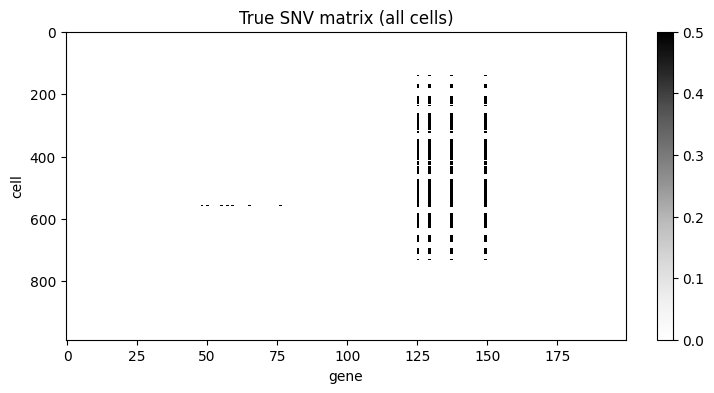

In [2]:
drivers = pd.read_csv(os.path.join(OUT, "tumor/gene_data/driver_types.csv"), index_col=0).iloc[:, 0]
n_onc = int((drivers == 1).sum()); n_tsg = int((drivers == -1).sum())
print(f"{len(drivers)} genes | {n_onc} oncogenes, {n_tsg} tumour suppressors")

true_snv = pd.read_csv(os.path.join(OUT, "tumor/cell_data/cell_snv.csv"), index_col=0)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(true_snv.values, aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("gene"); ax.set_ylabel("cell"); ax.set_title("True SNV matrix (all cells)")
plt.colorbar(im, ax=ax, fraction=0.046)

## Stage 2 — the biopsy sample

`isccsample` captured a subset of cells. Here are the sampled cells in space, against all cells.

{'fraction': 0.5, 'method': 'biopsy', 'n_input': 988, 'n_sampled': 494, 'seed': 2, 'source': '/Users/pedroferreira/projects/iscc/repo/notebooks/example_out/tumor'}


Text(0.5, 1.0, 'Biopsy: sampled cells')

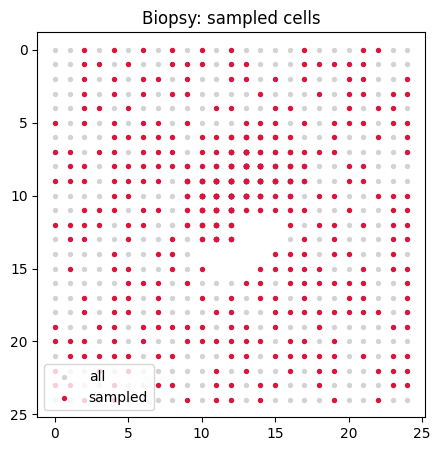

In [3]:
import yaml
meta = yaml.safe_load(open(os.path.join(OUT, "sample/sample_meta.yaml")))
print(meta)
all_crd = pd.read_csv(os.path.join(OUT, "tumor/cell_data/cell_crd.csv"), index_col=0)
samp_crd = pd.read_csv(os.path.join(OUT, "sample/cell_data/cell_crd.csv"), index_col=0)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(all_crd["col"], all_crd["row"], s=8, c="lightgrey", label="all")
ax.scatter(samp_crd["col"], samp_crd["row"], s=8, c="crimson", label="sampled")
ax.invert_yaxis(); ax.legend(); ax.set_title("Biopsy: sampled cells")

## Bulk DNA-seq

Bulk DNA pools the sampled cells. We get a per-gene coverage and alt-read count, from which we
read out the **variant allele frequency (VAF)** spectrum.

top variant genes: ['G_4_23', 'G_0_37', 'G_3_23', 'G_3_37', 'G_4_15']


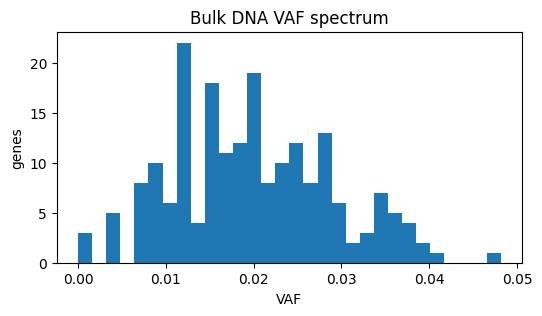

In [4]:
bdna = pd.read_csv(os.path.join(OUT, "data_bdna/counts.csv"), index_col=0)
vaf = (bdna["alt_counts"] / bdna["coverage"].replace(0, np.nan)).dropna()
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30); ax.set_xlabel("VAF"); ax.set_ylabel("genes"); ax.set_title("Bulk DNA VAF spectrum")
print("top variant genes:", list(vaf.sort_values(ascending=False).head(5).index))

## Single-cell DNA-seq

scDNA resolves SNVs per cell. We compute a per-cell VAF matrix (alt / coverage) — the substrate
for clone reconstruction.

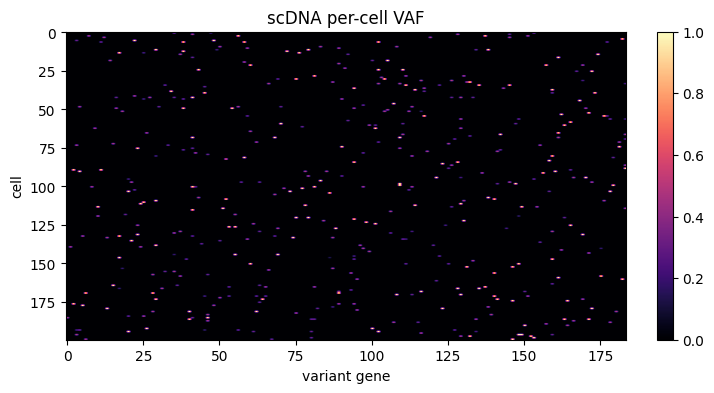

In [5]:
cov = pd.read_csv(os.path.join(OUT, "data_scdna/coverage.csv"), index_col=0)
alt = pd.read_csv(os.path.join(OUT, "data_scdna/alt_counts.csv"), index_col=0)
sc_vaf = (alt / cov.replace(0, np.nan)).fillna(0)
keep = sc_vaf.columns[sc_vaf.sum(0) > 0]  # genes with any signal
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(sc_vaf[keep].values, aspect="auto", cmap="magma")
ax.set_xlabel("variant gene"); ax.set_ylabel("cell"); ax.set_title("scDNA per-cell VAF")
plt.colorbar(im, ax=ax, fraction=0.046)

## Single-cell RNA-seq

scRNA gives UMI counts per cell. We load them into an `AnnData`, **annotate each cell with its
true type** (`adata.obs['cell_type']`), then run a standard scanpy workflow: QC, normalization,
PCA, neighbours, Leiden clustering and UMAP. Colouring the UMAP by the true cell type shows how
well the unsupervised clusters recover it.

In [6]:
umis = pd.read_csv(os.path.join(OUT, "data_scrna/umis.csv"), index_col=0)
adata = ad.AnnData(umis.astype("float32"))
# ground-truth cell-type annotation
adata.obs["cell_type"] = pd.Categorical(true_type.reindex(adata.obs_names).map(coarse_type))
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata)
print("cell-type annotations:", dict(adata.obs["cell_type"].value_counts()))

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cell-type annotations: {'stromal': 233, 'cancer': 161, 'epithelial': 6}


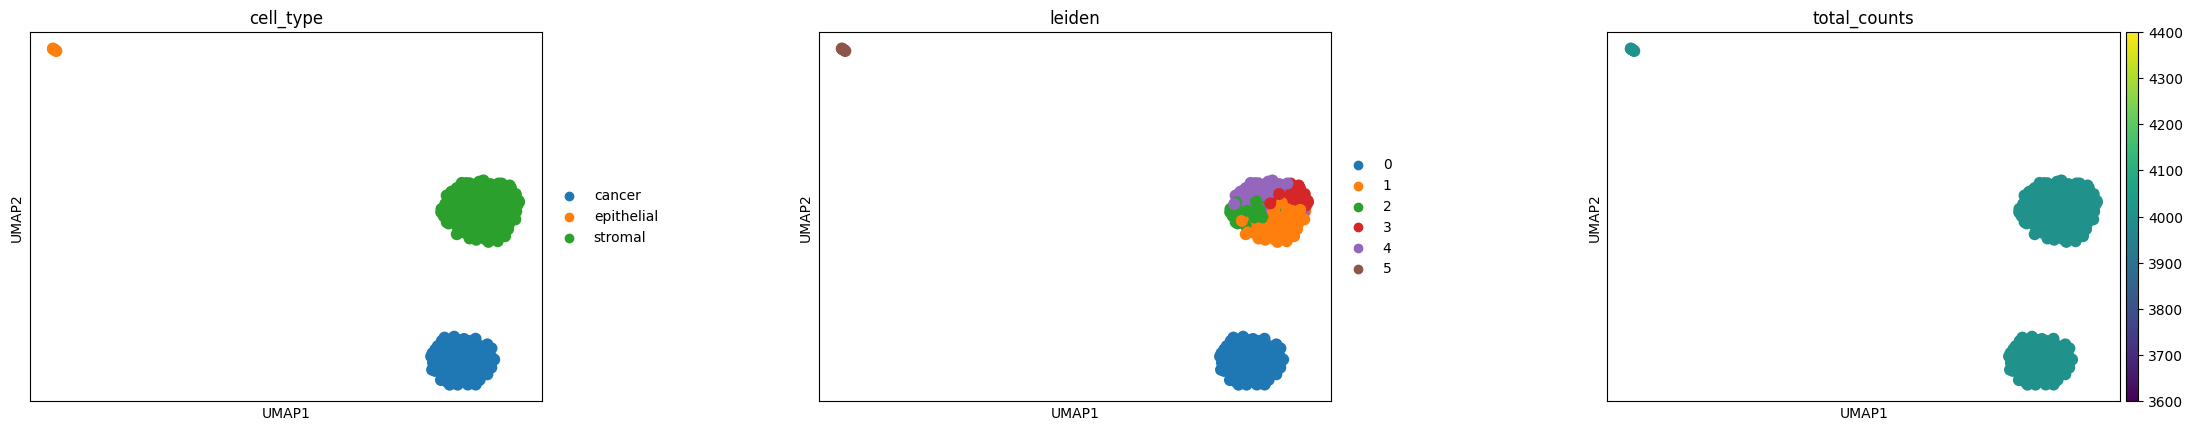

In [7]:
sc.pl.umap(adata, color=["cell_type", "leiden", "total_counts"], wspace=0.4)

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/scanpy/plotting/_tools/__init__.py:446: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ymin, ymax)


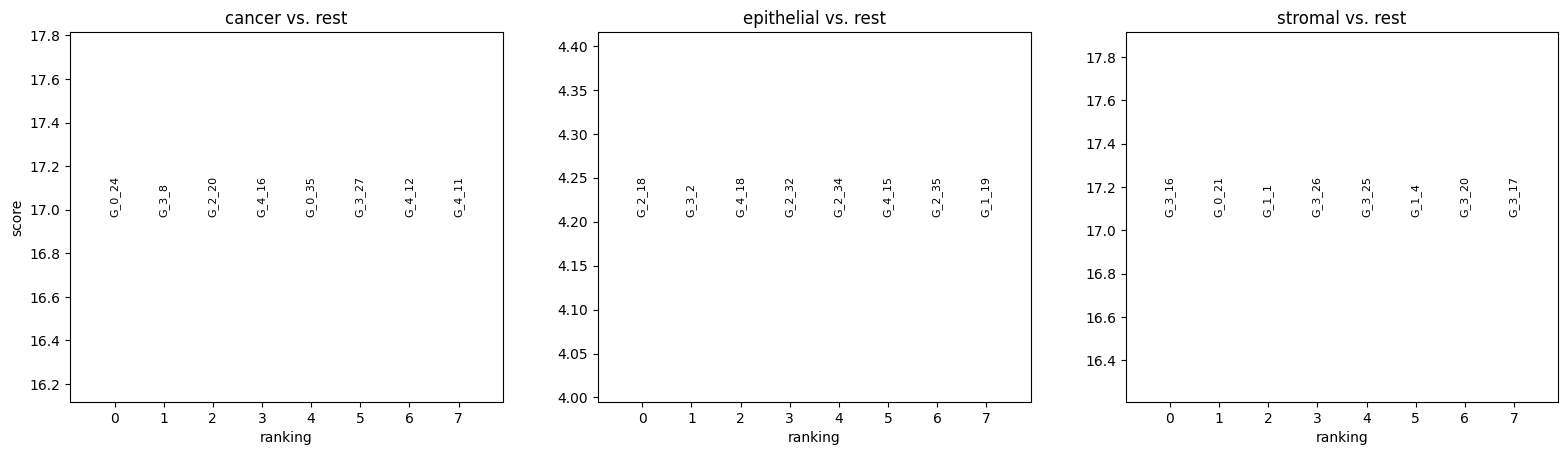

In [8]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=8, sharey=False)

## Visium spatial transcriptomics

Visium pools cells into spatial spots. We build an `AnnData` with spatial coordinates, annotate
each spot with its **dominant true cell type** (from the cells that fall in it), cluster the
spots into niches, and use squidpy to build a spatial neighbour graph.

In [9]:
spot = pd.read_csv(os.path.join(OUT, "data_visium/spot_umi.csv"), index_col=0)
crd = pd.read_csv(os.path.join(OUT, "data_visium/spot_crd.csv"), index_col=0)
spot_ids = pd.read_csv(os.path.join(OUT, "data_visium/spot_cell_ids.csv"), index_col=0)["cell_ids"].fillna("")

def dominant_type(cell_id_str):
    members = [c for c in str(cell_id_str).split(",") if c]
    if not members:
        return "empty"
    types = [coarse_type(true_type.get(c, "cancer")) for c in members]
    return pd.Series(types).mode().iloc[0]

vis = ad.AnnData(spot.astype("float32"))
vis.obsm["spatial"] = crd[["col", "row"]].values
vis.obs["cell_type"] = pd.Categorical(spot_ids.reindex(vis.obs_names).map(dominant_type))
sc.pp.filter_cells(vis, min_counts=1)        # drop empty spots
sc.pp.normalize_total(vis); sc.pp.log1p(vis)
sc.pp.pca(vis, n_comps=20); sc.pp.neighbors(vis)
sc.tl.leiden(vis, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sq.gr.spatial_neighbors(vis, coord_type="generic", n_neighs=6)
print("dominant spot types:", dict(vis.obs["cell_type"].value_counts()))

dominant spot types: {'stromal': 332, 'cancer': 56, 'epithelial': 10}


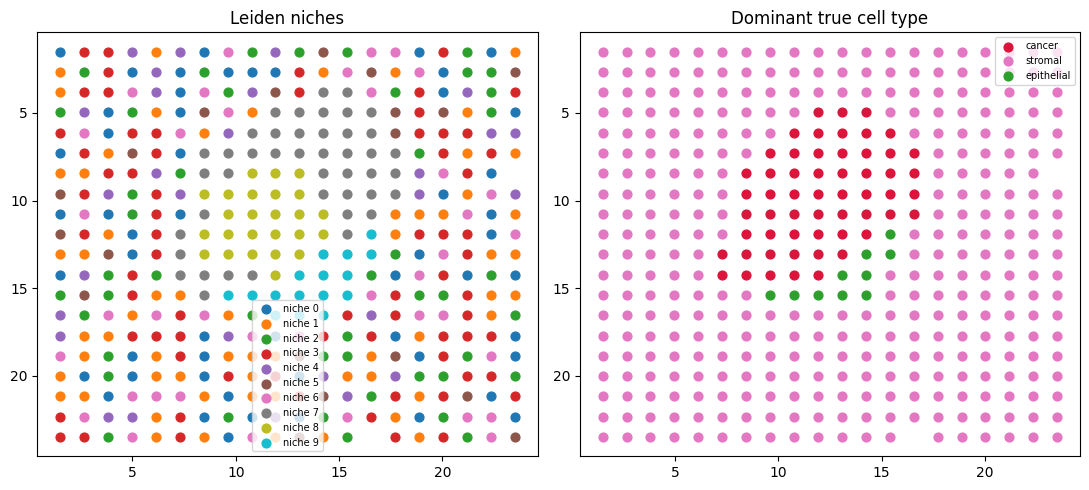

In [10]:
colors = {"cancer": "crimson", "stromal": "tab:pink", "epithelial": "tab:green",
          "immune": "gold", "empty": "lightgrey"}
sp = vis.obsm["spatial"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
# left: niches (unsupervised), right: dominant true cell type
for cl in sorted(vis.obs["leiden"].unique(), key=int):
    m = (vis.obs["leiden"] == cl).values
    axes[0].scatter(sp[m, 0], sp[m, 1], s=40, label=f"niche {cl}")
axes[0].set_title("Leiden niches"); axes[0].legend(fontsize=7)
for ct, col in colors.items():
    m = (vis.obs["cell_type"] == ct).values
    if m.any():
        axes[1].scatter(sp[m, 0], sp[m, 1], s=40, c=col, label=ct)
axes[1].set_title("Dominant true cell type"); axes[1].legend(fontsize=7)
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()

## Recap & roadmap

We took one simulated tumor and viewed it through bulk DNA, scDNA, scRNA and Visium — each a
noisy, partial measurement of the same ground truth. Because the ground truth (including each
cell's true type) is known, these datasets are ideal benchmarks for tumor-evolution methods.

On the roadmap (data realism): negative-binomial + dropout scRNA, allele-specific scDNA and a
read/FASTQ mode, and richer spatial spot mixing — plus the analysis-demo notebooks
(MHN from DNA, niche identification, batch effects, combining modalities, real-data comparison).